# 作业 1

## 2 概述、线性代数和 NDArray

### 2.1 理论计算题
已知向量 a = [2, −1, 3]⊤，b = [1, 4, −2]⊤，矩阵  
A = [−1 0 2; 1 3 1], B = [2 1 0; 3 2 −1]  
计算：  
1. 向量点积 a · b = 2*1 + (-1)*4 + 3*(-2) = -8；  
2. 矩阵乘法 A × B = [[2, -3], [4, 9]]（结果矩阵的形状 2×2）；  
3. 向量 a 的 Frobenius 范数 = √(4 + 1 + 9) = √14。

### 2.2 编程题
使用 NumPy（或 MXNet / PyTorch/TensorFlow）完成以下任务：

In [1]:
import numpy as np

# 1. 创建一个形状为 3 × 4 的随机矩阵 X，元素服从标准正态分布。
X = np.random.randn(3, 4)
print("X:")
print(X)

# 2. 创建一个形状为 4 × 2 的全 1 矩阵 Y。
Y = np.ones((4, 2))
print("\nY:")
print(Y)

# 3. 计算矩阵乘法 Z = X × Y。
Z = np.dot(X, Y)
print("\nZ:")
print(Z)

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素。
print("\nZ[0, 1]:", Z[0, 1])
print("Z 的第 2 行:", Z[1, :])

# 5. 计算 Z 的 Frobenius 范数。
frobenius_norm = np.linalg.norm(Z)
print("\nZ 的 Frobenius 范数:", frobenius_norm)

X:
[[-0.73597865  0.00209378  0.49510934 -0.96273369]
 [-0.00818313 -0.31639539 -0.81187244  0.69288907]
 [-1.46816704  1.28127148 -0.91856977  0.21225671]]

Y:
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z:
[[-1.20150922 -1.20150922]
 [-0.4435619  -0.4435619 ]
 [-0.89320862 -0.89320862]]

Z[0, 1]: -1.201509222959167
Z 的第 2 行: [-0.4435619 -0.4435619]

Z 的 Frobenius 范数: 2.2082541569394767


## 3 文档 2：概率与统计

### 3.1 理论计算题
某疾病在人群中的患病率为 0.1%。现有一种检测方法：  
• 若患病，检测呈阳性的概率为 99%（灵敏度）；  
• 若未患病，检测呈阳性的概率为 2%（假阳性率）。  
一个人检测结果为阳性，求他真正患病的概率（使用贝叶斯公式）。  

P(患病|阳性) = P(阳性|患病) * P(患病) / P(阳性) = 0.99 * 0.001 / (0.99*0.001 + 0.02*0.999) ≈ 0.0472

### 3.2 编程题
用 Python 模拟中心极限定理：

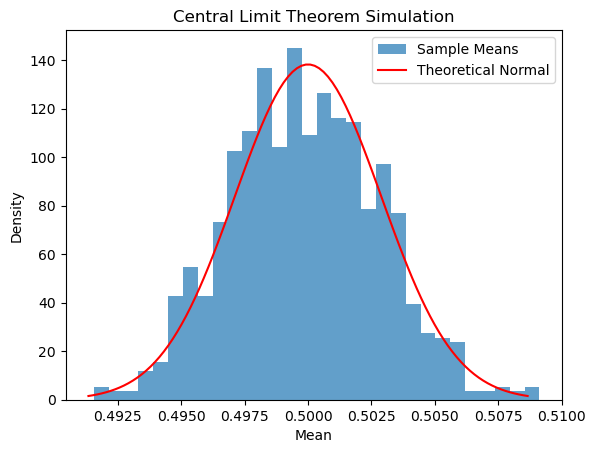

实际方差: 8.54078993762595e-06
理论方差: 8.333333333333334e-06


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. 生成 n = 10000 个服从均匀分布 U(0, 1) 的随机变量，重复 m = 1000 次，每次计算这 n 个变量的均值。
n = 10000
m = 1000
means = []
for _ in range(m):
    samples = np.random.uniform(0, 1, n)
    means.append(np.mean(samples))

means = np.array(means)

# 2. 绘制这 1000 个均值的直方图，并叠加理论正态分布的概率密度曲线。
plt.hist(means, bins=30, density=True, alpha=0.7, label='Sample Means')
mu = 0.5  # 理论均值
sigma = 1 / np.sqrt(12 * n)  # 理论标准差
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, norm.pdf(x, mu, sigma), 'r-', label='Theoretical Normal')
plt.legend()
plt.title('Central Limit Theorem Simulation')
plt.xlabel('Mean')
plt.ylabel('Density')
plt.show()

# 3. 计算这些均值的实际方差。
actual_variance = np.var(means)
print("实际方差:", actual_variance)
print("理论方差:", sigma**2)

## 4 文档 3：导数、反向传播和复杂度

### 4.1 理论计算题
给定函数 z = (w1x1 + w2x2 − y)^2，其中 x1 = 2, x2 = 1, y = 3 为常数，w1, w2 为变量。  
1. 分别计算 ∂z/∂w1 和 ∂z/∂w2 的表达式。  
   ∂z/∂w1 = 4(w1*2 + w2 - 3), ∂z/∂w2 = 2(2w1 + w2 - 3)  
2. 若当前 w1 = 0.5, w2 = 1，计算梯度值。  
   ∂z/∂w1 = -4, ∂z/∂w2 = -2

### 4.2 编程题
手动实现一个简单计算图的反向传播：

In [1]:
import torch

# 1. 定义前向计算：输入 x，经过 a = x · w1，b = a + w2，输出 L = b^2。
x = 2.0
w1 = 1.5
w2 = 0.5

# 前向
a = x * w1
b = a + w2
L = b ** 2
print("前向结果 L:", L)

# 2. 手动（按链式法则）计算损失 L 对 w1, w2 的梯度。
# L = b^2, b = a + w2, a = x * w1
# dL/db = 2b
# dL/dw2 = dL/db * db/dw2 = 2b * 1
# dL/da = dL/db * db/da = 2b * 1
# dL/dw1 = dL/da * da/dw1 = 2b * x

dL_dw2 = 2 * b * 1
dL_dw1 = 2 * b * x

print("手动计算梯度:")
print("dL/dw1:", dL_dw1)
print("dL/dw2:", dL_dw2)

# 3. 验证与自动微分工具（如 torch.autograd）的结果是否一致。
x_t = torch.tensor(x, requires_grad=False)
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2

L_t.backward()

print("自动微分梯度:")
print("dL/dw1:", w1_t.grad.item())
print("dL/dw2:", w2_t.grad.item())

前向结果 L: 12.25
手动计算梯度:
dL/dw1: 14.0
dL/dw2: 7.0
自动微分梯度:
dL/dw1: 14.0
dL/dw2: 7.0


## 5 文档 4：线性方法、基础优化和 SOFTMAX 回归

### 5.1 理论计算题
考虑线性回归模型 y = wx + b，使用均方误差损失 L = (1/n)∑(yi - (wxi + b))^2 推导损失对 w 和 b 的偏导数表达式（用求和形式）。  

∂L/∂w = -(2/n) ∑ (yi - w xi - b) xi  
∂L/∂b = -(2/n) ∑ (yi - w xi - b)

### 5.2 编程题
从零实现 softmax 回归对手写数字（MNIST）进行分类：

In [2]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. 使用 sklearn.datasets.load_digits() 或自己加载 MNIST 子集。
digits = load_digits()
X = digits.data
y = digits.target

# 2. 将图像展平为向量，对标签进行 one-hot 编码。
# 已经展平了，X.shape = (1797, 64)
# one-hot
num_classes = 10
y_onehot = np.zeros((y.shape[0], num_classes))
y_onehot[np.arange(y.shape[0]), y] = 1

# 3. 实现 softmax 函数、交叉熵损失函数。
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # 数值稳定
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-9), axis=1))

# 4. 使用小批量随机梯度下降（批量大小 32，学习率 0.1）训练模型 50 个 epoch。
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# 初始化权重
input_dim = X.shape[1]
W = np.random.randn(input_dim, num_classes) * 0.01
b = np.zeros(num_classes)

batch_size = 32
learning_rate = 0.1
epochs = 50

for epoch in range(epochs):
    indices = np.arange(X_train.shape[0])
    np.random.shuffle(indices)
    X_train_shuffled = X_train[indices]
    y_train_shuffled = y_train[indices]
    
    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]
        
        # 前向
        z = np.dot(X_batch, W) + b
        y_pred = softmax(z)
        
        # 损失
        loss = cross_entropy_loss(y_pred, y_batch)
        
        # 反向
        dz = y_pred - y_batch
        dW = np.dot(X_batch.T, dz) / batch_size
        db = np.mean(dz, axis=0)
        
        # 更新
        W -= learning_rate * dW
        b -= learning_rate * db
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# 5. 输出测试集上的准确率。
z_test = np.dot(X_test, W) + b
y_pred_test = softmax(z_test)
y_pred_labels = np.argmax(y_pred_test, axis=1)
y_true_labels = np.argmax(y_test, axis=1)
accuracy = np.mean(y_pred_labels == y_true_labels)
print("测试集准确率:", accuracy)

Epoch 0, Loss: 0.0555
Epoch 10, Loss: 0.0612
Epoch 20, Loss: 0.0000
Epoch 30, Loss: 0.0562
Epoch 40, Loss: 0.0001
测试集准确率: 0.9666666666666667


## 6 文档 5：最大似然估计和逻辑回归

### 6.1 理论计算题
假设样本 x1, x2, . . . , xn 独立同分布于正态分布 N (µ, σ^2)。  
1. 写出似然函数 L(µ, σ^2) = ∏_{i=1}^n (1/(σ√(2π))) exp( - (xi-µ)^2 / (2σ^2) )。  
2. 证明：µ 的最大似然估计为 µˆ = (1/n) ∑ xi。  
   对µ求导，设为0： ∑ (xi - µ) = 0 => µ = (1/n) ∑ xi  
3. 证明：σ^2 的最大似然估计为 σˆ^2 = (1/n) ∑(xi − µˆ)^2。  
   对σ^2求导，设为0： σ^2 = (1/n) ∑ (xi - µ)^2

### 6.2 编程题
实现二分类逻辑回归模型（不使用深度学习框架的高阶 API）：

Iteration 0, Loss: 0.6975
Iteration 100, Loss: 0.0321
Iteration 200, Loss: 0.0214
Iteration 300, Loss: 0.0172
Iteration 400, Loss: 0.0148
Iteration 500, Loss: 0.0133
Iteration 600, Loss: 0.0121
Iteration 700, Loss: 0.0112
Iteration 800, Loss: 0.0105
Iteration 900, Loss: 0.0099
测试集准确率: 1.0


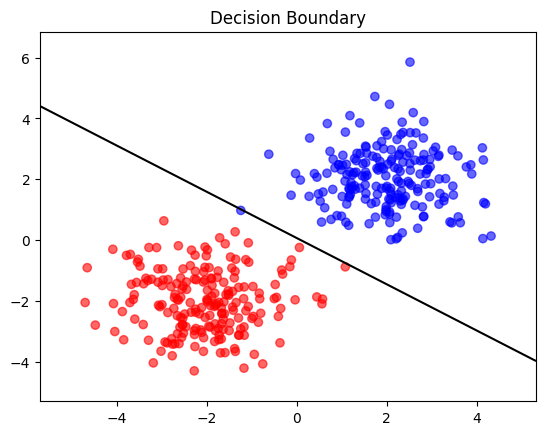

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成两类线性可分的数据：每类 200 个样本，特征维度为 2。
np.random.seed(42)
n_samples = 200
X1 = np.random.randn(n_samples, 2) + np.array([2, 2])
y1 = np.zeros(n_samples)
X2 = np.random.randn(n_samples, 2) + np.array([-2, -2])
y2 = np.ones(n_samples)
X = np.vstack([X1, X2])
y = np.hstack([y1, y2])

# 2. 定义 sigmoid 函数和二元交叉熵损失。
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    return -np.mean(y_true * np.log(y_pred + 1e-9) + (1 - y_true) * np.log(1 - y_pred + 1e-9))

# 3. 使用梯度下降法（学习率 0.1，迭代 1000 次）学习参数 w, b。
w = np.random.randn(2) * 0.01
b = 0.0
learning_rate = 0.1
iterations = 1000

for i in range(iterations):
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)
    loss = binary_cross_entropy(y_pred, y)
    
    dz = y_pred - y
    dw = np.dot(X.T, dz) / X.shape[0]
    db = np.mean(dz)
    
    w -= learning_rate * dw
    b -= learning_rate * db
    
    if i % 100 == 0:
        print(f"Iteration {i}, Loss: {loss:.4f}")

# 4. 绘制决策边界，并计算模型在测试集（新生成 100 个样本）上的分类准确率。
# 测试集
X_test1 = np.random.randn(50, 2) + np.array([2, 2])
y_test1 = np.zeros(50)
X_test2 = np.random.randn(50, 2) + np.array([-2, -2])
y_test2 = np.ones(50)
X_test = np.vstack([X_test1, X_test2])
y_test = np.hstack([y_test1, y_test2])

z_test = np.dot(X_test, w) + b
y_pred_test = sigmoid(z_test) > 0.5
accuracy = np.mean(y_pred_test == y_test)
print("测试集准确率:", accuracy)

# 绘制
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.6)
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100), np.linspace(x2_min, x2_max, 100))
Z = sigmoid(np.dot(np.c_[xx1.ravel(), xx2.ravel()], w) + b)
Z = Z.reshape(xx1.shape)
plt.contour(xx1, xx2, Z, levels=[0.5], colors='black')
plt.title('Decision Boundary')
plt.show()